In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch
import os
from matplotlib import pyplot as plt
# Set working directory
os.chdir("/pscratch/sd/g/gzhao27/INR/INR_SAMPLE/")

# Verify
print("Current working directory:", os.getcwd())

import sys
import torch.nn as nn
from torch.utils.data import DataLoader
import numpy as np
from torch_geometric.data import Data

from torch_geometric.data import Dataset, Data
from torch.utils.data import DataLoader
# from torch_geometric.loader import DataLoader
import argparse
from train_utility_sampling.train_utility import (
    split_graph_by_time,
    train_step,
    validation_step, 
    save_sampling_result,
    train_step_single_image,
    )

from utils.data.unstructure_dataset import (
    create_ns_dataset,
    )
from utils.data.unstructure_dataset import (
    GraphNavierStokes, 
    collate_graph_inr, 
    GraphSomaDataset, 
    GraphBurgers, 
    GraphNavierStokesSampling,
    get_graph_t_idx,
    )
# sys.path.append(str(Path(__file__).parents[1]))
# sys.path.append('/pscratch/sd/g/gzhao27/INR/coral')
from utils.load_inr import create_inr_instance, load_inr_model

from torchdiffeq import odeint
from torch_geometric.data import DataLoader as GDataLoader
import numpy as np
from train_utility_sampling.SamplerWrapper import (
    InrSamplerWrapper,
    graph_3d_cluster,
    graph_2d_cluster,
    add_cluster_label,
    sample_random_node_indices_per_cluster,
    INRSingle2dSamplerWrapper,
    graph_2d_cluster_single_image,
)
from mmap_ninja import RaggedMmap
from hydra import initialize, compose

# from train_utility_sampling.SamplerWrapper import InrSamplerWrapper, graph_3d_cluster, graph_2d_cluster, add_cluster_label, sample_random_node_indices_per_cluster
# from mmap_ninja import RaggedMmap
# from hydra import initialize, compose

# NS_inr_save_name = 'NS_keep_for_test_file'
# NS_inr_save_dir = '/pscratch/sd/g/gzhao27/INR/SOMA/results/best_result/'
device = torch.device('cuda')

Current working directory: /pscratch/sd/g/gzhao27/INR/INR_SAMPLE


In [3]:
def load_inr(i, model_dir):
    inr_save_path = os.path.join(model_dir, f"{i}.pt")
    inr_results = torch.load(inr_save_path, weights_only=False)
    cfg = inr_results['cfg']

    # create & load weights
    torch.set_default_dtype(torch.float32)
    inr = create_inr_instance(cfg, input_dim=2, output_dim=1, device=device)
    inr.load_state_dict(inr_results["inr"])
    inr.to(device).eval()
    return inr 

def grad_coor(grad1, grad2):
    return torch.dot(grad1, grad2)/torch.norm(grad1)/torch.norm(grad2)

def loss_function(features_recon, features):
    loss = features_recon
    loss = ((features_recon - features)**2)
    return loss

In [4]:
run_idx = {
    'null':260, 
    "random":7470,
    "EVOS": 3390, 
    "NMT": 550, 
    "cluster_grid": 4440
}

In [5]:
import os
import shutil

# Root path where you want to search
root_dir = "/pscratch/sd/g/gzhao27/INR/SOMA/results/inr_sampling"
run_path = {}
for dirpath, dirnames, filenames in os.walk(root_dir, topdown=True):
    for dirname in dirnames:
        for method in run_idx.keys():
            if "t100" in dirname and "depth_6" in dirname:
                if method == 'null':
                    if "null" in dirname:
                        if "5e-4" in dirname:
                            folder_path = os.path.join(dirpath, dirname)
                            run_path[method] = folder_path
                            print(folder_path)
                elif method == 'random':
                    if 'random' in dirname and "new" in dirname:
                        folder_path = os.path.join(dirpath, dirname)
                        run_path[method] = folder_path
                        print(folder_path)
                        
                elif "1e-4" in dirname and method in dirname and "08-15" in dirname:
                    folder_path = os.path.join(dirpath, dirname)
                    run_path[method] = folder_path
                    print(folder_path)
                    
                    # shutil.rmtree(folder_path)

/pscratch/sd/g/gzhao27/INR/SOMA/results/inr_sampling/2025-08-15-10-31-36NS1024_single_EVOS_0.001_lr_1e-4_depth_6_end_128_t100
/pscratch/sd/g/gzhao27/INR/SOMA/results/inr_sampling/2025-08-15-10-29-22NS1024_single_2d_cluster_grid_0.001_lr_1e-4_depth_6_end_128_t100
/pscratch/sd/g/gzhao27/INR/SOMA/results/inr_sampling/2025-08-16-20-26-07NS1024_single_random_0.001_lr_1e-4_depth_6_end_128_t100new
/pscratch/sd/g/gzhao27/INR/SOMA/results/inr_sampling/2025-08-15-14-20-15NS1024_single_null_0.001_lr_5e-4_depth_6_end_128_t100
/pscratch/sd/g/gzhao27/INR/SOMA/results/inr_sampling/2025-08-15-10-22-22NS1024_single_NMT_0.001_lr_1e-4_depth_6_end_128_t100


In [6]:
model_dir= run_path['null']
ite = run_idx['null']
model_path = os.path.join(model_dir, f'{ite}.pt')
save_results = torch.load(model_path, weights_only = False, map_location=device)
cfg = save_results['cfg']
#wandb
run_name = cfg.wandb.name

#data
data_path = cfg.data.data_path
dataset_name = cfg.data.dataset_name
split_ratios = tuple(cfg.data.split_ratios)
space_factor = cfg.data.space_factor
time_factor = cfg.data.time_factor
seed = cfg.data.seed

ntrain = cfg.data.ntrain
ntest = cfg.data.ntest
data_type = cfg.data.data_type
mmap_dir = cfg.data.mmap_dir
data_to_encode = cfg.data.data_to_encode
val_missing_rate = cfg.data.val_missing_rate
sub_array_num = cfg.data.sub_array_num

# optim
batch_size = cfg.optim.batch_size
batch_size_val = (
    batch_size if cfg.optim.batch_size_val == None else cfg.optim.batch_size_val
)
lr_inr = cfg.optim.lr_inr  # lr_inr is learning parameter initial value, also the meta learning rate
lr_code = cfg.optim.lr_code 
meta_lr_code = cfg.optim.meta_lr_code # meta learning rate to learn
weight_decay_code = cfg.optim.weight_decay_code
inner_steps = cfg.optim.inner_steps
epochs = cfg.optim.epochs

# inr
model_type = cfg.inr.model_type
latent_dim = cfg.inr.latent_dim



In [7]:
trainset = create_ns_dataset(
            datapath = data_path, 
            data_type=data_type, 
            seed=seed,
            single_image=True  # If True, only use one image from the dataset
        )
train_loader = DataLoader(dataset=trainset, batch_size=1, shuffle=True, collate_fn=collate_graph_inr)
graph = next(iter(train_loader))
t = cfg.data.single_time_frame  # Use this to time frame
indices_t = get_graph_t_idx(graph, t)

graph = Data(
    cor=graph.cor[indices_t],
    feat=graph.feat[indices_t],
    time=torch.zeros(len(indices_t)),  # set time to 0 tensor
    space_emb=graph.space_emb[indices_t],
    T=torch.tensor(1),
)

In [8]:
exist_iter = {}
def find_closest_iter_file(model_dir, target_iter=210):
    files = [f for f in os.listdir(model_dir) if f.endswith(".pt")]
    
    # Extract iteration numbers
    iters = []
    for f in files:
        try:
            iter_num = int(os.path.splitext(f)[0])  # remove .pt and convert
            iters.append((iter_num, f))
        except ValueError:
            continue  # skip files that don't match the pattern
    
    if not iters:
        return None
    
    # Find closest iteration
    closest_iter, closest_file = min(iters, key=lambda x: abs(x[0] - target_iter))
    
    return closest_iter


for method in run_idx.keys():
    ite = run_idx[method]
    model_dir = run_path[method]
    exist_iter[method] = find_closest_iter_file(model_dir, ite)

/tmp/ipykernel_1933335/1743384192.py:71: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  im = ax.imshow(np.abs(dif), vmin=dif_vmin, vmax=dif_vmax, cmap="jet")


tensor(4.5680)
tensor(1.9857)
tensor(2.0326)
tensor(7.5292)
tensor(0.4492)


/tmp/ipykernel_1933335/1743384192.py:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.925, 1])


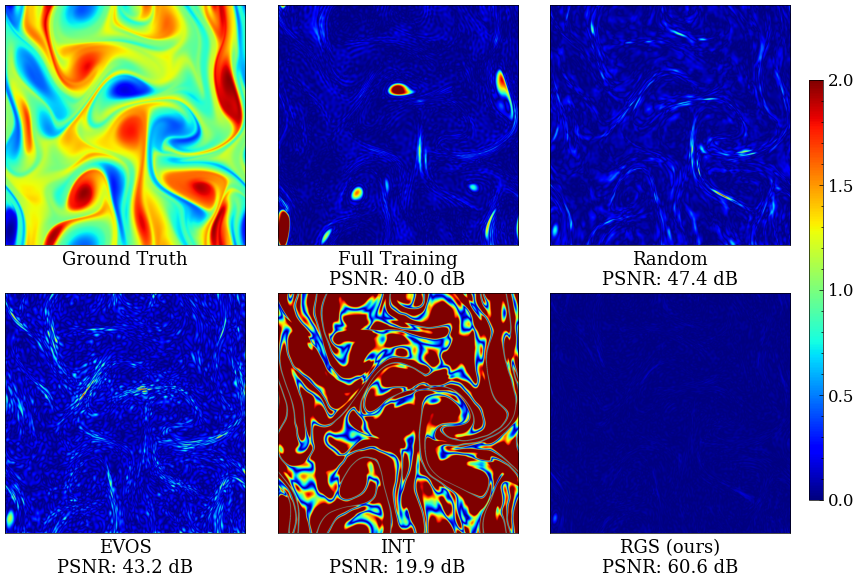

Figure X: Error maps (reconstruction minus ground truth) for INR variants. Top-left: ground truth. Remaining panels: per-method difference images in a 2×3 layout, using a fixed, symmetric color scale (0.0 to 2.0). PSNR values (dB) are reported in titles. Reconstructions are visually indistinguishable due to high PSNR, so error maps are shown for clarity. PSNR by method — null: 40.0 dB; random: 47.4 dB; EVOS: 43.2 dB; NMT: 19.9 dB; cluster_grid: 60.6 dB.


In [16]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

import scienceplots

plt.style.use('science')

import matplotlib as mpl
mpl.rcParams['text.usetex'] = False

torch.cuda.empty_cache()
graph = graph.to(device)
H = graph.cor.max().item() + 1

features = graph.feat.view(H, H, 1)
coords = graph.space_emb.detach().view(H, H, 2)

gt_vmin, gt_vmax = -17, 14
dif_vmin, dif_vmax = 0, 2.0
cbar_ticks = np.linspace(dif_vmin, dif_vmax, 5)


method_display_names = {
    'EVOS': 'EVOS',
    'NMT': 'INT', 
    'cluster_grid': 'RGS (ours)',
    'random': 'Random',
    'null': 'Full Training'
}

def compute_psnr(x: torch.Tensor, y: torch.Tensor, data_range: float = None) -> float:
    x_ = x.float()
    y_ = y.float()
    mse = torch.mean((x_ - y_) ** 2).item()
    if mse == 0:
        return float("inf")
    if data_range is None:
        data_range = (x_.max() - x_.min()).item()
    return 10.0 * np.log10((data_range ** 2) / mse)

data_range = (features.max() - features.min()).item()

# --- Make a 2x3 subplot grid ---
fig, axes = plt.subplots(2, 3, figsize=(9, 6))
axes = axes.flatten()  # turn into 1D list

# Ground truth in first panel
ax_gt = axes[0]
im_gt = ax_gt.imshow(features.cpu(), vmin=gt_vmin, vmax=gt_vmax, cmap="jet")
np.save('gt.pny', features.cpu())
ax_gt.set_xlabel("Ground Truth\n", fontsize=13)
ax_gt.set_xticks([])
ax_gt.set_yticks([])

# Fill difference maps in remaining slots
psnr_table = {}
with torch.no_grad():
    for ax, method in zip(axes[1:], run_idx.keys()):
        model_dir = run_path[method]
        ite = exist_iter[method]
        inr = load_inr(ite, model_dir).to(device)

        reconfeature = inr(coords)
        dif = (reconfeture := reconfeature.detach().cpu()) - features.cpu()
        np.save(f'{method}.npy', reconfeture, )
        psnr_val = compute_psnr(features.cpu(), reconfeture.cpu(), data_range=data_range)
        psnr_table[method] = psnr_val

        im = ax.imshow(np.abs(dif), vmin=dif_vmin, vmax=dif_vmax, cmap="jet")
        print(dif.max())
        ax.set_xlabel(f"{method_display_names[method]}\nPSNR: {psnr_val:.1f} dB", fontsize=13)
        ax.set_xticks([])
        ax.set_yticks([])

# Hide unused subplots (if fewer than 5 methods)
for ax in axes[1+len(run_idx):]:
    ax.axis("off")

# Shared colorbar on the right
cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.formatter = ticker.FormatStrFormatter("%.1f")
cbar.set_ticks(cbar_ticks, )
cbar.ax.tick_params(labelsize=12)
cbar.update_ticks()

plt.tight_layout(rect=[0, 0, 0.925, 1])
plt.subplots_adjust(hspace=0.2)


fig.savefig('dif-compare.pdf', 
           format='pdf', 
           dpi=300, 
           bbox_inches='tight',
           facecolor='white',
           edgecolor='none')
plt.show()

# Caption for paper
methods_psnr_str = "; ".join([f"{m}: {psnr_table[m]:.1f} dB" for m in run_idx.keys()])
caption = (
    "Figure X: Error maps (reconstruction minus ground truth) for INR variants. "
    "Top-left: ground truth. Remaining panels: per-method difference images in a 2×3 layout, "
    f"using a fixed, symmetric color scale ({dif_vmin:.1f} to {dif_vmax:.1f}). "
    "PSNR values (dB) are reported in titles. Reconstructions are visually indistinguishable "
    f"due to high PSNR, so error maps are shown for clarity. PSNR by method — {methods_psnr_str}."
)
print(caption)




In [12]:
def sample_multiple_from_intervals(bounds, n_samples, device='cuda'):
    """
    Sample multiple integers from each interval.
    
    Args:
        bounds: tensor of shape (n_intervals, 2)
        n_samples: number of samples per interval
        device: device to run on
    
    Returns:
        tensor of shape (n_intervals, n_samples)
    """
    bounds = bounds.to(device)
    n_intervals = len(bounds)
    
    # Expand bounds for vectorized sampling
    low = bounds[:, 0].unsqueeze(1).expand(n_intervals, n_samples)
    high = bounds[:, 1].unsqueeze(1).expand(n_intervals, n_samples)
    
    rand_vals = torch.rand(n_intervals, n_samples, device=device)
    samples = low + torch.floor(rand_vals * (high - low + 1)).long()
    
    return samples

def generate_equal_bins(low, high, n_bins, device='cuda'):
    """
    Generate bin bounds with similar widths (max difference = 1).
    
    Args:
        low: lower bound of the range
        high: upper bound of the range (inclusive)
        n_bins: number of bins to create
        device: device to run on
    
    Returns:
        tensor of shape (n_bins, 2) containing [start, end] for each bin
    """
    device = torch.device(device)
    
    # Total range (inclusive)
    total_range = high - low + 1
    
    # Base width for each bin
    base_width = total_range // n_bins
    
    # Number of bins that need one extra element
    remainder = total_range % n_bins
    
    # Create bin bounds
    bounds = torch.zeros(n_bins, 2, dtype=torch.long, device=device)
    
    current_pos = low
    for i in range(n_bins):
        # First 'remainder' bins get base_width + 1, others get base_width
        width = base_width + (1 if i < remainder else 0)
        
        bounds[i, 0] = current_pos  # start of bin
        bounds[i, 1] = current_pos + width - 1  # end of bin (inclusive)
        
        current_pos += width
    
    return bounds

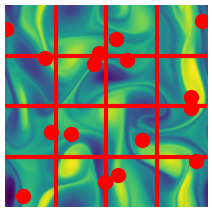

In [14]:

plt.imshow(graph.feat.cpu().numpy().reshape(1024, 1024))
plt.axis('off')
n_bins = 4


bounds = generate_equal_bins(0, 1024-1, n_bins, device='cpu')  # Example usage on CPU
cor = sample_multiple_from_intervals(bounds, n_bins*2, device='cpu')  # Example usage on CPU
cor1 = cor[:, :n_bins]
cor2 = cor[:, n_bins:].T

grid_positions = [1024//n_bins*i for i in range(1, n_bins)]
for x in grid_positions:
    plt.axvline(x=x + 0.5, color='r', linewidth=3)
    plt.axhline(y=x + 0.5, color='r', linewidth=3)
    
    
plt.scatter(cor1.flatten(), cor2.flatten(), color='red', s= 100)
    

# count = 0
# for i in range(len(grid_positions) - 1):
#     for j in range(len(grid_positions) - 1):
#         # centre of the cell in pixel coordinates
#         x_center = (grid_positions[j] + grid_positions[j+1]) / 2 - 0.5
#         y_center = (grid_positions[i] + grid_positions[i+1]) / 2 - 0.5
#         plt.text(x_center, y_center, str(count),
#                  ha='center', va='center',
#                  color='blue', fontsize=12)
# plt.figure(figsize=(10, 5))
# plt.imshow(features_recon.cpu().detach().numpy(), cmap='jet')

In [21]:
y = 2
(x := y)

2